## Exercise 7: Simulated Annealing for the Travelling Salesman Problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

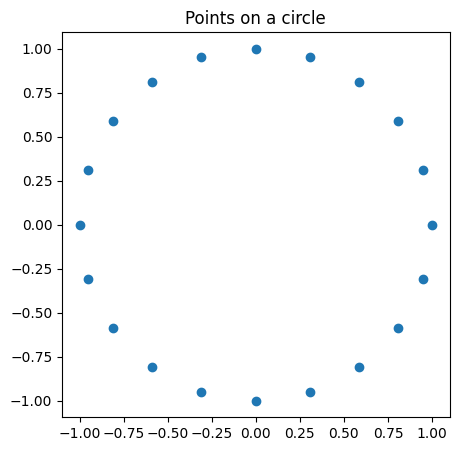

In [2]:
np.random.seed(42)
n = 20

# Points on a circle
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
points = np.column_stack([np.cos(angles), np.sin(angles)])

# Plot the points
plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1])
plt.title("Points on a circle")
plt.axis('equal')
plt.show()

In [3]:
def route_cost(route, points):
    """Total Euclidean distance of a route."""
    total = 0
    n = len(route)
    for i in range(n):
        a = points[route[i]]
        b = points[route[(i + 1) % n]]
        total += np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
    return total

def swap_proposal(route):
    """Swap two randomly chosen cities."""
    new_route = route.copy()
    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def cooling(k):
    return 1 / np.sqrt(1 + k)

Simulated Annealing algorithm

In [ ]:
def simulated_annealing(points, n_iter=50000, cooling_func=cooling):
    n = len(points)
    
    # Start with a random route
    current_route = list(np.random.permutation(n))
    current_cost = route_cost(current_route, points)
    best_route = current_route.copy()
    best_cost = current_cost
    cost_history = [current_cost]

    for k in range(n_iter):
        T = cooling_func(k)
        candidate = swap_proposal(current_route)
        candidate_cost = route_cost(candidate, points)
        
        delta = candidate_cost - current_cost
        if delta < 0 or np.random.uniform() < np.exp(-delta / T):
            current_route = candidate
            current_cost = candidate_cost
        
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost
        
        cost_history.append(current_cost)
    
    return best_route, best_cost, cost_history

# Run on circle points
best_route, best_cost, cost_history = simulated_annealing(points)
print(f"Best cost foound: {best_cost:.4f}")
print(f"Expected (full circle): {2 * np.pi:.4f}")

Best cost found: 6.2574
Expected (full circle): 6.2832


Plot the best route

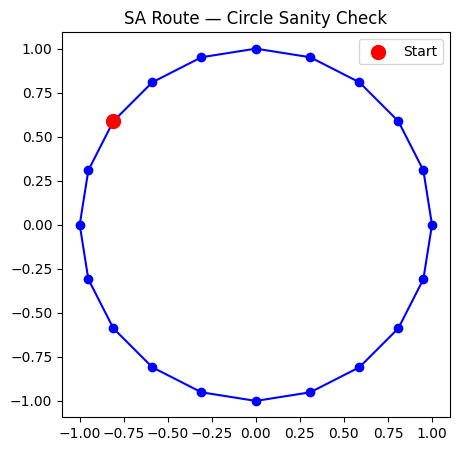

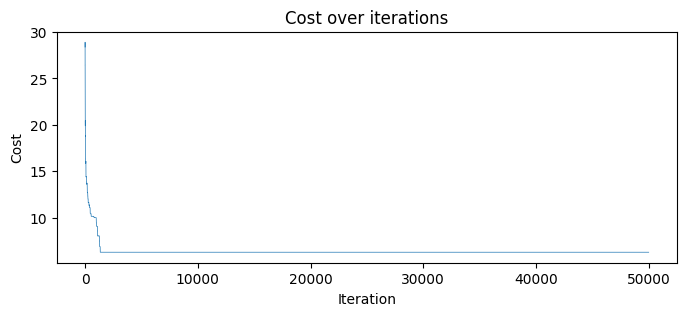

In [5]:
def plot_route(points, route, title="SA Route"):
    route_closed = route + [route[0]]  # close the loop
    xs = [points[i][0] for i in route_closed]
    ys = [points[i][1] for i in route_closed]
    
    plt.figure(figsize=(5, 5))
    plt.plot(xs, ys, 'b-o', markersize=6)
    plt.scatter(points[route[0]][0], points[route[0]][1], 
                color='red', s=100, zorder=5, label='Start')
    plt.title(title)
    plt.axis('equal')
    plt.legend()
    plt.show()

plot_route(points, best_route, title="SA Route — Circle Sanity Check")

# Also plot cost history
plt.figure(figsize=(8, 3))
plt.plot(cost_history, lw=0.5)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost over iterations")
plt.show()

Part 2

TSP with general cost matrix

In [10]:
def route_cost_matrix(route, A):
    """Total cost using a cost matrix."""
    n = len(route)
    return sum(A[route[i]][route[(i+1) % n]] for i in range(n))

def simulated_annealing_matrix(A, n_iter=50000, cooling_func=cooling):
    n = len(A)
    current_route = list(np.random.permutation(n))
    current_cost = route_cost_matrix(current_route, A)
    best_route = current_route.copy()
    best_cost = current_cost
    cost_history = [current_cost]

    for k in range(n_iter):
        T = cooling_func(k)
        candidate = swap_proposal(current_route)
        candidate_cost = route_cost_matrix(candidate, A)
        delta = candidate_cost - current_cost
        if delta < 0 or np.random.uniform() < np.exp(-delta / T):
            current_route = candidate
            current_cost = candidate_cost
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost
        cost_history.append(current_cost)

    return best_route, best_cost, cost_history


In [11]:
import pandas as pd

A = pd.read_csv('cost.csv', header=None).values
print(f"Number of cities: {len(A)}")

np.random.seed(42)
best_route, best_cost, cost_history = simulated_annealing_matrix(A)
print(f"Best route (1-indexed): {[r+1 for r in best_route]}")
print(f"Best cost: {best_cost}")

Number of cities: 20
Best route (1-indexed): [np.int32(16), np.int32(14), np.int32(2), np.int32(9), np.int32(19), np.int32(15), np.int32(12), np.int32(6), np.int32(17), np.int32(7), np.int32(18), np.int32(3), np.int32(11), np.int32(20), np.int32(13), np.int32(4), np.int32(1), np.int32(8), np.int32(5), np.int32(10)]
Best cost: 878


Compare cooling schedules

Sqrt cooling — best cost: 878, route: [np.int32(16), np.int32(14), np.int32(2), np.int32(9), np.int32(19), np.int32(15), np.int32(12), np.int32(6), np.int32(17), np.int32(7), np.int32(18), np.int32(3), np.int32(11), np.int32(20), np.int32(13), np.int32(4), np.int32(1), np.int32(8), np.int32(5), np.int32(10)]
Log  cooling — best cost: 878,  route: [np.int32(16), np.int32(14), np.int32(2), np.int32(9), np.int32(19), np.int32(15), np.int32(12), np.int32(6), np.int32(17), np.int32(7), np.int32(18), np.int32(3), np.int32(11), np.int32(20), np.int32(13), np.int32(4), np.int32(1), np.int32(8), np.int32(5), np.int32(10)]


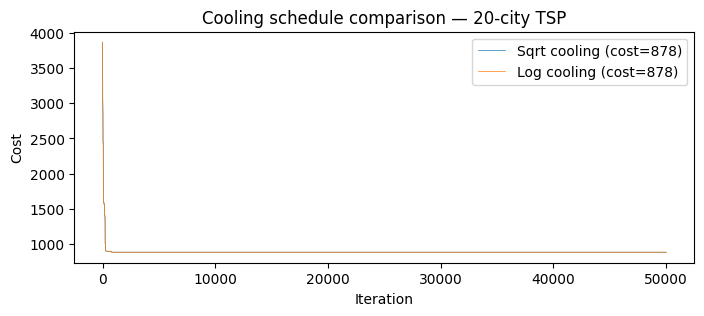

In [12]:
def cooling_sqrt(k):
    return 1 / np.sqrt(1 + k)

def cooling_log(k):
    return 1 / np.log(2 + k)

np.random.seed(42)
route_sqrt, cost_sqrt, history_sqrt = simulated_annealing_matrix(A, cooling_func=cooling_sqrt)
np.random.seed(42)
route_log, cost_log, history_log = simulated_annealing_matrix(A, cooling_func=cooling_log)

print(f"Sqrt cooling — best cost: {cost_sqrt}, route: {[r+1 for r in route_sqrt]}")
print(f"Log  cooling — best cost: {cost_log},  route: {[r+1 for r in route_log]}")

plt.figure(figsize=(8, 3))
plt.plot(history_sqrt, lw=0.5, label=f'Sqrt cooling (cost={cost_sqrt})')
plt.plot(history_log,  lw=0.5, label=f'Log cooling (cost={cost_log})')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cooling schedule comparison — 20-city TSP")
plt.legend()
plt.show()

Geometric cooling — best cost: 802
Best route (1-indexed): [np.int32(17), np.int32(11), np.int32(20), np.int32(3), np.int32(19), np.int32(15), np.int32(2), np.int32(14), np.int32(9), np.int32(5), np.int32(8), np.int32(16), np.int32(10), np.int32(1), np.int32(13), np.int32(4), np.int32(6), np.int32(12), np.int32(18), np.int32(7)]


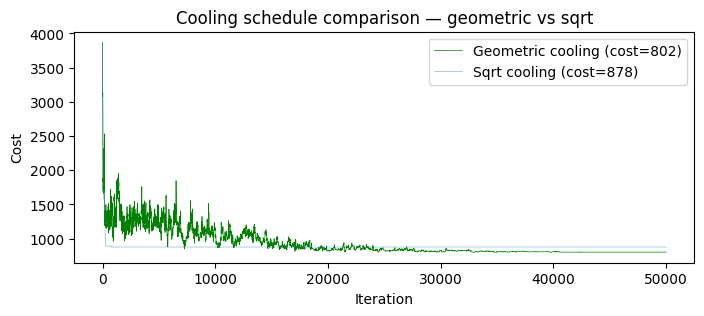

In [13]:
def cooling_geometric(k, alpha=0.9999, T0=100):
    return T0 * (alpha ** k)

np.random.seed(42)
route_geo, cost_geo, history_geo = simulated_annealing_matrix(A, n_iter=50000, 
                                                               cooling_func=cooling_geometric)

print(f"Geometric cooling — best cost: {cost_geo}")
print(f"Best route (1-indexed): {[r+1 for r in route_geo]}")

plt.figure(figsize=(8, 3))
plt.plot(history_geo, lw=0.5, color='green', label=f'Geometric cooling (cost={cost_geo})')
plt.plot(history_sqrt, lw=0.5, alpha=0.5, label=f'Sqrt cooling (cost={cost_sqrt})')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cooling schedule comparison — geometric vs sqrt")
plt.legend()
plt.show()

There is a clear improvement

The trade-off is visible inn the plot. Geometric cooling oscillates much longer before settling, while sqrt converges almost instantly but gets stuck in a worse local optimum.